# Bloch Sphere Visualizer using Qiskit

## Project Overview

The aim of this project is to visualize how common single-qubit quantum gates affect the state of a qubit on the Bloch sphere.

The Bloch sphere provides a geometric representation of quantum states and allows quantum gate operations to be interpreted as rotations in three-dimensional space.

## Theory

A single qubit can be represented as:

|ψ⟩ = α|0⟩ + β|1⟩

The Bloch sphere provides a geometric representation of a single qubit state.


X Gate
Bloch Coordinates: (0.000, 0.000, -1.000)


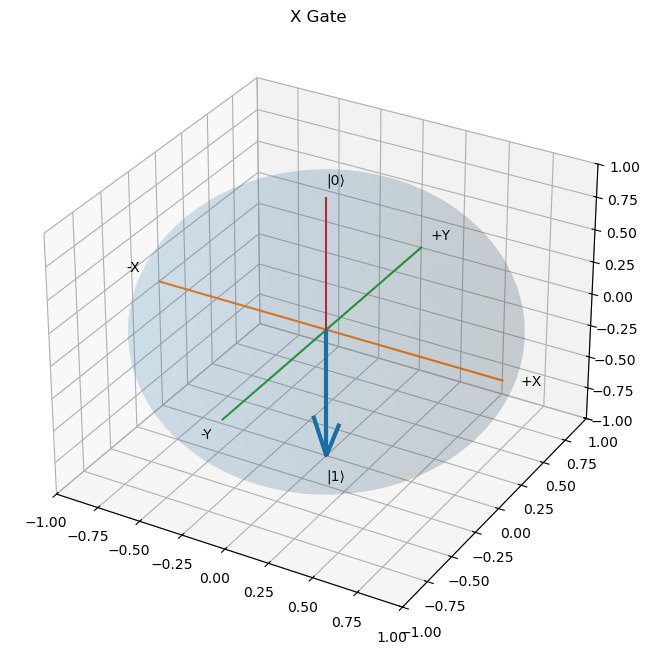


Y Gate
Bloch Coordinates: (0.000, 0.000, -1.000)


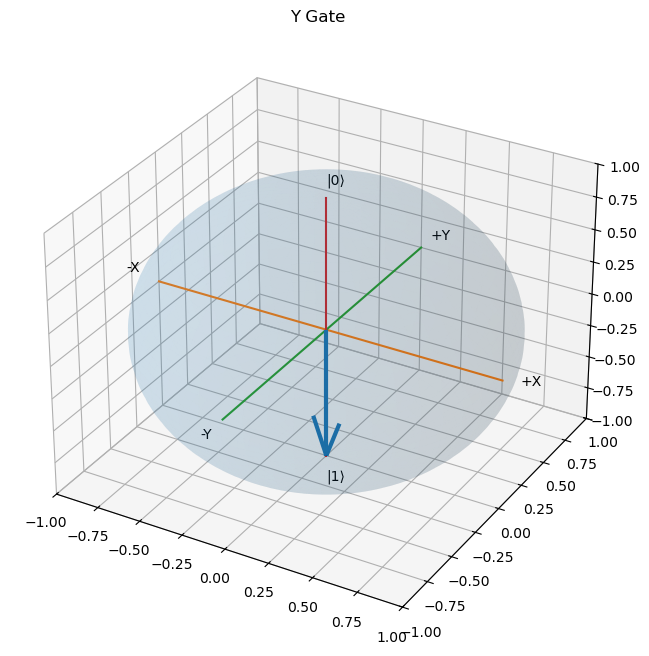


Z Gate
Bloch Coordinates: (0.000, 0.000, 1.000)


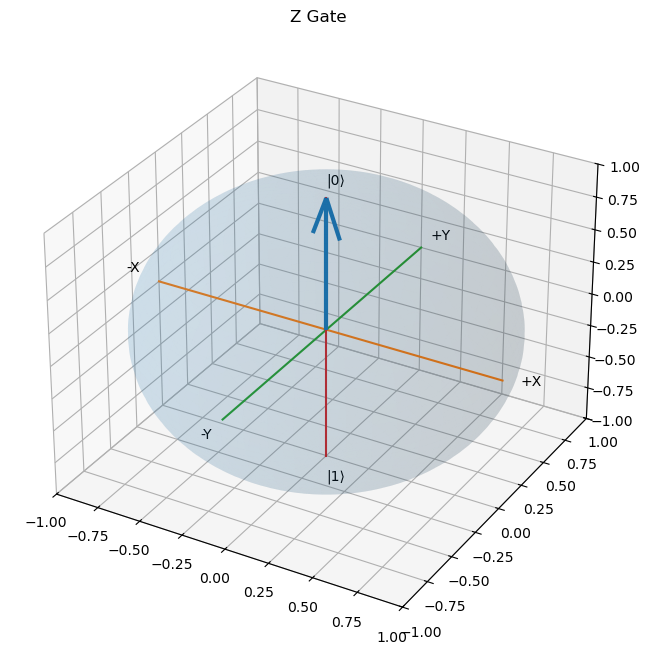


H Gate
Bloch Coordinates: (1.000, 0.000, 0.000)


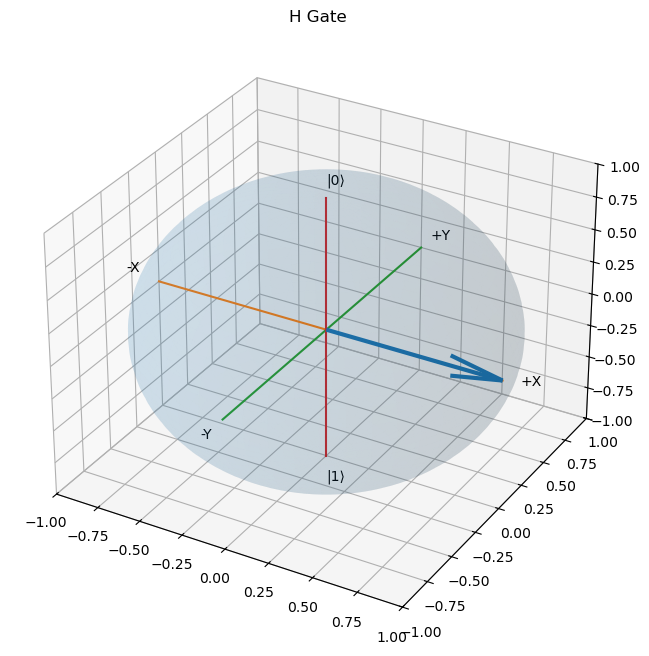


S Gate
Bloch Coordinates: (0.000, 0.000, 1.000)


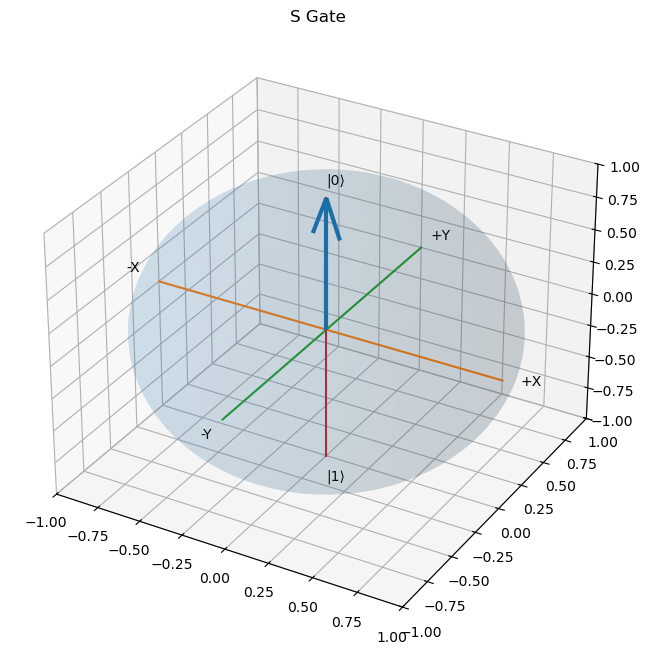


T Gate
Bloch Coordinates: (0.000, 0.000, 1.000)


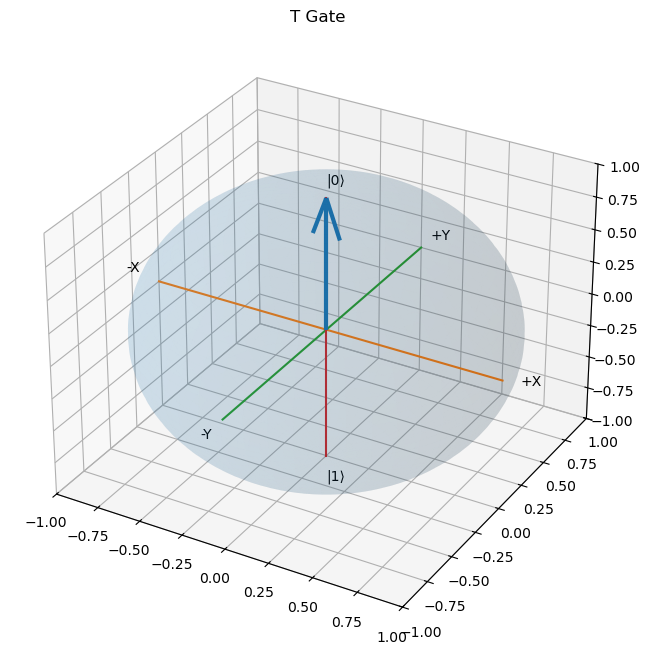

In [14]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

import numpy as np
import matplotlib.pyplot as plt


def state_to_bloch(state):
    """
    Convert a single-qubit statevector to Bloch coordinates.
    """

    alpha = state.data[0]
    beta = state.data[1]

    x = 2 * np.real(np.conjugate(alpha) * beta)
    y = 2 * np.imag(np.conjugate(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2

    return x, y, z


def plot_bloch_sphere(x, y, z, title="Bloch Sphere"):

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_surface(
        xs,
        ys,
        zs,
        alpha=0.1
    )

    # Axes
    ax.plot([-1, 1], [0, 0], [0, 0])
    ax.plot([0, 0], [-1, 1], [0, 0])
    ax.plot([0, 0], [0, 0], [-1, 1])

    # State vector
    ax.quiver(
        0, 0, 0,
        x, y, z,
        linewidth=3
    )

    ax.text(1.1, 0, 0, "+X")
    ax.text(-1.2, 0, 0, "-X")

    ax.text(0, 1.1, 0, "+Y")
    ax.text(0, -1.2, 0, "-Y")

    ax.text(0, 0, 1.1, "|0⟩")
    ax.text(0, 0, -1.2, "|1⟩")

    ax.set_title(title)

    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

    plt.show()


def visualize_gate(gate):

    qc = QuantumCircuit(1)

    if gate == "X":
        qc.x(0)

    elif gate == "Y":
        qc.y(0)

    elif gate == "Z":
        qc.z(0)

    elif gate == "H":
        qc.h(0)

    elif gate == "S":
        qc.s(0)

    elif gate == "T":
        qc.t(0)

    else:
        raise ValueError("Unsupported gate")

    state = Statevector.from_instruction(qc)

    x, y, z = state_to_bloch(state)

    print(f"\n{gate} Gate")
    print(f"Bloch Coordinates: ({x:.3f}, {y:.3f}, {z:.3f})")

    plot_bloch_sphere(
        x,
        y,
        z,
        title=f"{gate} Gate"
    )


if __name__ == "__main__":

    visualize_gate("X")
    visualize_gate("Y")
    visualize_gate("Z")
    visualize_gate("H")
    visualize_gate("S")
    visualize_gate("T")

## X Gate

The X gate acts as a quantum NOT gate and transforms:

|0⟩ → |1⟩


X Gate
Bloch Coordinates: (0.000, 0.000, -1.000)


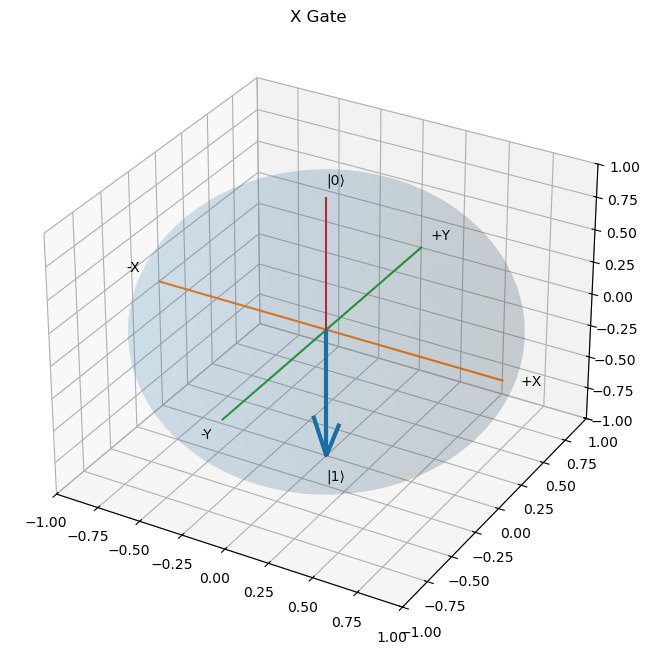

In [15]:
visualize_gate("X")

## Hadamard Gate

The Hadamard gate creates a superposition state.

|0⟩ → (|0⟩ + |1⟩)/√2

In [ ]:
visualize_gate("H")

## Conclusion

This project demonstrates how quantum gates transform single-qubit states on the Bloch sphere.